In [3]:
from langchain_openai import ChatOpenAI
from langgraph.graph import StateGraph,START,END,add_messages
from typing import TypedDict,Annotated,List
from dotenv import load_dotenv
from pydantic import BaseModel,Field
import operator
from langchain_core.messages import BaseMessage

In [4]:
class Task(BaseModel):

    id : int
    title : str = Field(required = True,description = 'Title of the task')
    brief : str = Field(required= True,decription = 'A detailed explanation about the given title')

In [6]:
class Plan(BaseModel):

    blog_title : str = Field(required=True,description = 'Title of the blog')
    task : List[Task]

In [8]:

class BlogState(TypedDict):

    topic : str
    plan : List[Plan]
    section : Annotated[List[str],operator.add]


In [24]:
def orchestrator(state:BlogState)->dict:
    pass

In [25]:
def worker(state:BlogState)->dict:
    pass

In [26]:
def reducer(state:BlogState)->dict:
    pass

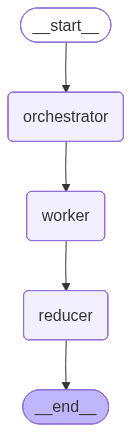

In [28]:
graph = StateGraph(BlogState)

graph.add_node('orchestrator',orchestrator)
graph.add_node('worker',worker)
graph.add_node('reducer',reducer)

graph.add_edge(START,'orchestrator')
graph.add_edge('orchestrator','worker')
graph.add_edge('worker','reducer')
graph.add_edge('reducer',END)

blog = graph.compile()

blog